# Linking Health Datasets: UCI Chronic Kidney Disease + CKD Clinical Analysis

## Student Exercise Notebook

**Course:** I 320D - Data Science for Biomedical Informatics
**Instructor:** Ammar Darkazanli
**Semester:** Spring 2026

---

### 🎯 This Week's Mantra

# "One Patient, Many Datasets"

*Translation: No single dataset tells the whole story. Learning to combine data sources is a core real-world skill.*

---

## Instructions

1. Complete each cell marked with `# TODO:`
2. Run your code to verify it works
3. Use the hints provided if you get stuck
4. Ask questions during class if needed!

---

### Learning Objectives

By the end of this exercise, you will be able to:

1. Load and compare two kidney disease datasets with drastically different schemas (abbreviated vs. descriptive column names)
2. Harmonize features across datasets (string vs. integer encoding, single vs. split BP, ordinal vs. continuous albumin)
3. Combine datasets vertically with `pd.concat`
4. Build lookup tables with `groupby` and enrich sparse lab records with GFR, medications, and lifestyle data
5. Use a trained model to generate CKD-risk scores across datasets

---

### Notebook Sections
| Part | Topic | Strategy |
|------|-------|----------|
| 1 | Setup and Load Data | — |
| 2 | Schema Harmonization | — |
| 3 | Vertical Stack | `pd.concat` |
| 4 | Aggregate Enrichment | `groupby` + `merge` |
| 5 | Train-Transfer | Model as Bridge |
| 6 | Challenge Exercises | All strategies |

---

### 📋 Dataset Overview

| | UCI CKD | CKD Clinical Analysis |
|---|---|---|
| **Source** | UCI ML Repository | Kaggle (rabieelkharoua) |
| **Kaggle slug** | `mansoordaku/ckdisease` | `rabieelkharoua/chronic-kidney-disease-dataset-analysis` |
| **Rows** | 400 | ~1,659 |
| **Columns** | 25 (abbreviated names) | ~50 (descriptive CamelCase names) |
| **Target** | `classification` (ckd/notckd strings) | `Diagnosis` (0/1 binary) |
| **Encoding style** | Strings: "yes"/"no", "normal"/"abnormal" | Integers: 0/1 |
| **Missing values** | Abundant (encoded as "?", "\t?", NaN) | Minimal |
| **Key additions** | — | GFR, HbA1c, medications, lipid panel, QoL score |

---
# PART 1: Setup and Load Data
---

### 1.1 Import Libraries

In [66]:
# In case you need the installs

!pip install pandas --quiet
!pip install numpy --quiet
!pip install matplotlib --quiet
!pip install seaborn --quiet
!pip install scipy --quiet
!pip install scikit-learn --quiet

In [67]:
# TODO: Import the required libraries
# - pandas as pd
# - numpy as np
# - matplotlib.pyplot as plt
# - seaborn as sns
# - from sklearn.linear_model import LogisticRegression
# - from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# Display settings (run this after importing)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported!")

Libraries Imported!


### 1.2 Load the Datasets

> **Download instructions:** Download both CSVs from Kaggle and place them in the same folder as this notebook.
>
> ```bash
> kaggle datasets download -d mansoordaku/ckdisease
> kaggle datasets download -d rabieelkharoua/chronic-kidney-disease-dataset-analysis
> ```
>
> **UCI CKD:** Classic UCI repository dataset — lean lab panel with messy real-world encoding.
> **CKD Clinical Analysis:** Richer clinical dataset — includes GFR, medications, lipid panel, and quality of life scores.

In [3]:
# TODO: Load both datasets
# UCI CKD: 'kidney_disease.csv' (comma-separated)
# CKD Clinical: 'kidney_disease_data.csv' (comma-separated)
# Note: UCI CKD has messy values like '?' and '\t?' — we'll handle those soon

uci = pd.read_csv('kidney_disease.csv')
clinical = pd.read_csv('Chronic_Kidney_Dsease_data.csv')

print(f"UCI CKD:          {uci.shape[0]:,} rows x {uci.shape[1]} columns")
print(f"CKD Clinical:     {clinical.shape[0]:,} rows x {clinical.shape[1]} columns")

UCI CKD:          400 rows x 26 columns
CKD Clinical:     1,659 rows x 54 columns


### 1.3 Explore Both Datasets

In [4]:
# TODO: Display the first 5 rows of the UCI CKD dataset
# Notice the abbreviated column names!

print("UCI CKD first 5 rows:")
uci.head()

UCI CKD first 5 rows:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [5]:
# TODO: Display the first 5 rows of the CKD Clinical dataset
# Notice the descriptive CamelCase column names (UpperCase naming convention)

print("CKD Clinical first 5 rows")
clinical.head()

CKD Clinical first 5 rows


,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes,PreviousAcuteKidneyInjury,UrinaryTractInfections,SystolicBP,DiastolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,ProteinInUrine,ACR,SerumElectrolytesSodium,SerumElectrolytesPotassium,SerumElectrolytesCalcium,SerumElectrolytesPhosphorus,HemoglobinLevels,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,ACEInhibitors,Diuretics,NSAIDsUse,Statins,AntidiabeticMedications,Edema,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,0.240386,4.076434,0,0,0,0,0,113,83,72.510788,9.212397,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,207.728670,85.863656,21.967957,212.095215,0,0,4.563139,1,0,0,3.563894,6.992244,4.518513,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,6.503233,7.652813,1,1,0,0,0,120,67,100.848875,4.604989,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,189.450727,86.378670,87.569756,255.451314,0,0,9.097002,0,0,0,5.327336,0.356290,2.202222,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,2.104828,4.392786,0,0,0,0,0,147,106,160.989441,5.432599,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,284.137622,132.269872,20.049798,251.902583,0,1,3.851249,1,0,0,4.855420,4.674069,5.967271,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,6.964422,6.282274,0,0,0,0,0,117,65,188.506620,4.144466,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,235.112124,93.443669,58.260291,392.338425,0,0,7.881765,0,0,0,8.531685,5.691455,2.176387,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,3.097796,4.021639,0,0,0,0,0,98,66,82.156699,4.262979,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,258.277566,171.758356,21.583213,370.523877,1,1,4.179459,1,0,0,1.422320,2.273459,6.800993,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


In [6]:
# TODO: Print the columns and dtypes for both datasets
# Hint: Use .dtypes or .info()

print("UCI CKD COLUMNS:")
print(uci.dtypes)

print("\nCKD CLINICAL COLUMNS:")
print(clinical.dtypes)

UCI CKD COLUMNS:
id                  int64
age               float64
bp                float64
sg                float64
al                float64
su                float64
rbc                object
pc                 object
pcc                object
ba                 object
bgr               float64
bu                float64
sc                float64
sod               float64
pot               float64
hemo              float64
pcv                object
wc                 object
rc                 object
htn                object
dm                 object
cad                object
appet              object
pe                 object
ane                object
classification     object
dtype: object

CKD CLINICAL COLUMNS:
PatientID                          int64
Age                                int64
Gender                             int64
Ethnicity                          int64
SocioeconomicStatus                int64
EducationLevel                     int64
BMI                     

### 📋 UCI CKD Column Decoder

The UCI dataset uses cryptic 2-3 letter abbreviations. Here's what they mean:

| Code | Full Name | Type | Unit/Values |
|------|-----------|------|-------------|
| `age` | Age | Numeric | Years |
| `bp` | Blood Pressure | Numeric | mmHg (diastolic) |
| `sg` | Specific Gravity | Numeric | 1.005–1.025 |
| `al` | Albumin | Ordinal | 0–5 (categorical scale) |
| `su` | Sugar | Ordinal | 0–5 (categorical scale) |
| `rbc` | Red Blood Cells | Categorical | "normal" / "abnormal" |
| `pc` | Pus Cell | Categorical | "normal" / "abnormal" |
| `pcc` | Pus Cell Clumps | Categorical | "present" / "notpresent" |
| `ba` | Bacteria | Categorical | "present" / "notpresent" |
| `bgr` | Blood Glucose Random | Numeric | mg/dL |
| `bu` | Blood Urea | Numeric | mg/dL |
| `sc` | Serum Creatinine | Numeric | mg/dL |
| `sod` | Sodium | Numeric | mEq/L |
| `pot` | Potassium | Numeric | mEq/L |
| `hemo` | Hemoglobin | Numeric | g/dL |
| `pcv` | Packed Cell Volume | Numeric | % |
| `wc` | White Blood Cell Count | Numeric | cells/cumm |
| `rc` | Red Blood Cell Count | Numeric | millions/cumm |
| `htn` | Hypertension | Categorical | "yes" / "no" |
| `dm` | Diabetes Mellitus | Categorical | "yes" / "no" |
| `cad` | Coronary Artery Disease | Categorical | "yes" / "no" |
| `appet` | Appetite | Categorical | "good" / "poor" |
| `pe` | Pedal Edema | Categorical | "yes" / "no" |
| `ane` | Anemia | Categorical | "yes" / "no" |
| `classification` | CKD Diagnosis | Target | "ckd" / "notckd" |

### 📋 Feature Alignment Map

| Feature | UCI Column | UCI Format | Clinical Column | Clinical Format | Harmonization Needed |
|---------|-----------|-----------|----------------|-----------------|---------------------|
| Age | `age` | Float (years) | `Age` | Int (years) | Minimal |
| Blood Pressure | `bp` | Single diastolic (mmHg) | `SystolicBP`, `DiastolicBP` | Two columns (mmHg) | UCI has only diastolic |
| Serum Creatinine | `sc` | Float (mg/dL) | `SerumCreatinine` | Float (mg/dL) | Rename only |
| Blood Urea | `bu` | Float (mg/dL) | `BUNLevels` | Float (mg/dL) | Rename only |
| Sodium | `sod` | Float (mEq/L) | `SerumElectrolytesSodium` | Float (mEq/L) | Rename only |
| Potassium | `pot` | Float (mEq/L) | `SerumElectrolytesPotassium` | Float (mEq/L) | Rename only |
| Hemoglobin | `hemo` | Float (g/dL) | `HemoglobinLevels` | Float (g/dL) | Rename only |
| Edema | `pe` | "yes"/"no" string | `Edema` | 0/1 integer | Recode string → int |
| Hypertension | `htn` | "yes"/"no" string | — (derivable from BP) | — | Different representation |
| Diabetes | `dm` | "yes"/"no" string | — (derivable from HbA1c) | — | Flag vs. continuous |
| GFR | — | **Not available** | `GFR` | Float (mL/min) | Unique to Clinical |
| HbA1c | — | **Not available** | `HbA1c` | Float (%) | Unique to Clinical |
| Medications | — | **Not available** | Multiple columns | 0/1 | Unique to Clinical |
| Lipid Panel | — | **Not available** | 4 columns | Float | Unique to Clinical |
| Quality of Life | — | **Not available** | `QualityOfLifeScore` | Float | Unique to Clinical |

> ⚠️ **Key Insight:** The UCI dataset is a compact lab panel with **messy real-world data** (missing values encoded as "?"). The Clinical dataset is a richer, cleaner EHR-style record. This reflects the reality that older clinical databases often have cryptic schemas and messy encoding, while newer systems use standardized formats.

### 1.4 Data Validation

In [7]:
# TODO: Validate the UCI CKD dataset
# Check: how many '?' and '\t?' values exist? What columns have them?
# Also check: age range, classification distribution
# Hint: (uci == '?').sum() or uci.isin(['?', '\t?']).sum()

print("="*60)
print("UCI CKD VALIDATION")
print("="*60)

missing_uci_mark = (uci == '?').sum().sum()                                          
missing_uci_t = (uci == '\t?').sum().sum()
                                                                            
print(f"Count of '?' values: {missing_uci_mark}")
print(f"Count of '\\t?' values: {missing_uci_t}")

# Show which columns have missing values
missing_byCol_mark = (uci == '?').sum()
missing_byCol_t = (uci == '\t?').sum()

print("\nColumns with '?':")
print(missing_byCol_mark[missing_byCol_mark > 0])

print("\nColumns with '\\t?':")
print(missing_byCol_t[missing_byCol_t > 0])

uci['classification'] = uci['classification'].str.strip()
print(f"\nAge range: {uci['age'].min()} to {uci['age'].max()}")
print("\nClassification distribution:")
print(uci['classification'].value_counts())

UCI CKD VALIDATION
Count of '?' values: 0
Count of '\t?' values: 3

Columns with '?':
Series([], dtype: int64)

Columns with '\t?':
pcv    1
wc     1
rc     1
dtype: int64

Age range: 2.0 to 90.0

Classification distribution:
classification
ckd       250
notckd    150
Name: count, dtype: int64


In [8]:
# TODO: Validate the CKD Clinical dataset
# Check: missing values, Age range, Diagnosis distribution,
#        GFR range, SerumCreatinine range
# Hint: clinical.describe(), clinical['Diagnosis'].value_counts()

print("="*60)
print("CKD CLINICAL VALIDATION")
print("="*60)                                                                
              
# Check for missing values
print(f"\nMissing values per column:")
print(clinical.isnull().sum())
print(f"\nTotal missing: {clinical.isnull().sum().sum()}")

# Age range
print(f"\nAge range: {clinical['Age'].min()} to {clinical['Age'].max()}")

# Diagnosis distribution
print("\nDiagnosis distribution:")
print(clinical['Diagnosis'].value_counts())
print(f"CKD rate: {clinical['Diagnosis'].mean()*100:.1f}%")

# GFR range
print(f"\nGFR range: {clinical['GFR'].min():.1f} to {clinical['GFR'].max():.1f}")
print(f"GFR mean: {clinical['GFR'].mean():.1f}")

# SerumCreatinine range
print(f"\nSerum Creatinine range: {clinical['SerumCreatinine'].min():.2f} to {clinical['SerumCreatinine'].max():.2f}")
print(f"Serum Creatinine mean: {clinical['SerumCreatinine'].mean():.2f}")

# Summary statistics
print("\nSummary statistics for key columns:")
print(clinical[['Age', 'GFR', 'SerumCreatinine', 'Diagnosis']].describe())                                                              

CKD CLINICAL VALIDATION

Missing values per column:
PatientID                        0
Age                              0
Gender                           0
Ethnicity                        0
SocioeconomicStatus              0
EducationLevel                   0
BMI                              0
Smoking                          0
AlcoholConsumption               0
PhysicalActivity                 0
DietQuality                      0
SleepQuality                     0
FamilyHistoryKidneyDisease       0
FamilyHistoryHypertension        0
FamilyHistoryDiabetes            0
PreviousAcuteKidneyInjury        0
UrinaryTractInfections           0
SystolicBP                       0
DiastolicBP                      0
FastingBloodSugar                0
HbA1c                            0
SerumCreatinine                  0
BUNLevels                        0
GFR                              0
ProteinInUrine                   0
ACR                              0
SerumElectrolytesSodium          0
Ser

---
# PART 2: Schema Harmonization
---

Before linking, we need both datasets to speak the **same language**. This is the hardest part — and the most realistic.

### 2.1 Clean UCI Missing Values

The UCI dataset encodes missing values as `'?'`, `'\t?'`, and sometimes `' ?'` (with leading spaces/tabs). Replace all of these with `NaN`.

In [9]:
# TODO: Replace all '?' variants with NaN in the UCI dataset
# Then convert numeric columns to their proper types
# Hint: uci = uci.replace(['?', '\t?', ' ?', '\t'], np.nan)
#        Then use pd.to_numeric() on columns that should be numeric

uci_clean = uci.copy()
                                                                            
# Step 1: Replace ? with NaN
uci_clean = uci_clean.replace(['?', '\t?', ' ?', '\t'], np.nan)

# Step 2: Convert numeric columns to float
numeric_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod',
              'pot', 'hemo', 'pcv', 'wc', 'rc']
for col in numeric_cols:
  uci_clean[col] = pd.to_numeric(uci_clean[col], errors='coerce')

print("Missing values per column:")
print(uci_clean.isnull().sum())
print(f"\nTotal missing: {uci_clean.isnull().sum().sum()}")

Missing values per column:
id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                71
wc                106
rc                131
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

Total missing: 1012


### 2.2 Rename UCI Columns to Readable Names

Replace the cryptic abbreviations with descriptive names that match the Clinical dataset.

In [10]:
# TODO: Rename UCI CKD columns using the mapping below
# Hint: uci_clean = uci_clean.rename(columns=rename_map)

rename_map = {
    'age': 'age',
    'bp': 'diastolic_bp',
    'sg': 'specific_gravity',
    'al': 'albumin_ordinal',
    'su': 'sugar_ordinal',
    'rbc': 'rbc_status',
    'pc': 'pus_cell',
    'pcc': 'pus_cell_clumps',
    'ba': 'bacteria',
    'bgr': 'blood_glucose',
    'bu': 'blood_urea',
    'sc': 'serum_creatinine',
    'sod': 'sodium',
    'pot': 'potassium',
    'hemo': 'hemoglobin',
    'pcv': 'packed_cell_volume',
    'wc': 'wbc_count',
    'rc': 'rbc_count',
    'htn': 'hypertension',
    'dm': 'diabetes',
    'cad': 'coronary_artery_disease',
    'appet': 'appetite',
    'pe': 'pedal_edema',
    'ane': 'anemia',
    'classification': 'ckd_diagnosis'
}

uci_clean = uci_clean.rename(columns=rename_map)

print("Renamed UCI columns:")
print(uci_clean.columns.tolist())

Renamed UCI columns:
['id', 'age', 'diastolic_bp', 'specific_gravity', 'albumin_ordinal', 'sugar_ordinal', 'rbc_status', 'pus_cell', 'pus_cell_clumps', 'bacteria', 'blood_glucose', 'blood_urea', 'serum_creatinine', 'sodium', 'potassium', 'hemoglobin', 'packed_cell_volume', 'wbc_count', 'rbc_count', 'hypertension', 'diabetes', 'coronary_artery_disease', 'appetite', 'pedal_edema', 'anemia', 'ckd_diagnosis']


### 2.3 Encode UCI String Categoricals to Binary

UCI uses "yes"/"no", "normal"/"abnormal", "present"/"notpresent" strings. Convert to 0/1.

In [11]:
# TODO: Convert string categorical columns to binary 0/1
# Mappings:
#   "yes" -> 1, "no" -> 0  (for hypertension, diabetes, cad, pedal_edema, anemia)
#   "good" -> 1, "poor" -> 0  (for appetite)
#   "normal" -> 0, "abnormal" -> 1  (for rbc_status, pus_cell)
#   "present" -> 1, "notpresent" -> 0  (for pus_cell_clumps, bacteria)
#   "ckd" -> 1, "notckd" -> 0  (for ckd_diagnosis)
#
# Hint: Handle extra whitespace! Some values have leading/trailing spaces or tabs.
#        Use .str.strip() first: uci_clean['col'] = uci_clean['col'].str.strip()

# Step 1: Strip whitespace from ALL string columns
str_cols = uci_clean.select_dtypes(include='object').columns
for col in str_cols:
    uci_clean[col] = uci_clean[col].str.strip()

# Step 2: Apply Mappings
mappings = {
  'yes_no': {'yes': 1, 'no': 0},
  'good_poor': {'good': 1, 'poor': 0},
  'normal_abnormal': {'normal': 0, 'abnormal': 1},
  'present_notpresent': {'present': 1, 'notpresent': 0},
  'ckd_notckd': {'ckd': 1, 'notckd': 0}
}

for col in ['hypertension', 'diabetes', 'coronary_artery_disease', 'pedal_edema', 'anemia']:
  uci_clean[col] = uci_clean[col].map(mappings['yes_no'])

uci_clean['appetite'] = uci_clean['appetite'].map(mappings['good_poor'])

for col in ['rbc_status', 'pus_cell']:
  uci_clean[col] = uci_clean[col].map(mappings['normal_abnormal'])

for col in ['pus_cell_clumps', 'bacteria']:
  uci_clean[col] = uci_clean[col].map(mappings['present_notpresent'])

uci_clean['ckd_diagnosis'] = uci_clean['ckd_diagnosis'].map(mappings['ckd_notckd'])

# Verify
print("UCI binary columns after encoding:")
for col in ['hypertension', 'diabetes', 'coronary_artery_disease', 'pedal_edema', 'anemia', 'appetite', 'rbc_status', 'pus_cell',
'ckd_diagnosis']:
  print(f"  {col}: {uci_clean[col].value_counts(dropna=False).to_dict()}")

UCI binary columns after encoding:
  hypertension: {0.0: 251, 1.0: 147, nan: 2}
  diabetes: {0.0: 261, 1.0: 137, nan: 2}
  coronary_artery_disease: {0.0: 364, 1.0: 34, nan: 2}
  pedal_edema: {0.0: 323, 1.0: 76, nan: 1}
  anemia: {0.0: 339, 1.0: 60, nan: 1}
  appetite: {1.0: 317, 0.0: 82, nan: 1}
  rbc_status: {0.0: 201, nan: 152, 1.0: 47}
  pus_cell: {0.0: 259, 1.0: 76, nan: 65}
  ckd_diagnosis: {1: 250, 0: 150}


### 2.4 Standardize CKD Clinical Column Names

The Clinical dataset uses CamelCase. Standardize to snake_case for consistency.

In [12]:
# TODO: Convert Clinical column names to snake_case
# Hint: Use a regex or manual approach
# Simple approach: clinical.columns = clinical.columns.str.replace(r'(?<=[a-z])(?=[A-Z])', '_', regex=True).str.lower()

clinical.columns = clinical.columns.str.replace(r'(?<=[a-z])(?=[A-Z])', '_', regex=True).str.lower()

print("Standardized Clinical columns:")
print(clinical.columns.tolist())

Standardized Clinical columns:
['patient_id', 'age', 'gender', 'ethnicity', 'socioeconomic_status', 'education_level', 'bmi', 'smoking', 'alcohol_consumption', 'physical_activity', 'diet_quality', 'sleep_quality', 'family_history_kidney_disease', 'family_history_hypertension', 'family_history_diabetes', 'previous_acute_kidney_injury', 'urinary_tract_infections', 'systolic_bp', 'diastolic_bp', 'fasting_blood_sugar', 'hb_a1c', 'serum_creatinine', 'bunlevels', 'gfr', 'protein_in_urine', 'acr', 'serum_electrolytes_sodium', 'serum_electrolytes_potassium', 'serum_electrolytes_calcium', 'serum_electrolytes_phosphorus', 'hemoglobin_levels', 'cholesterol_total', 'cholesterol_ldl', 'cholesterol_hdl', 'cholesterol_triglycerides', 'aceinhibitors', 'diuretics', 'nsaids_use', 'statins', 'antidiabetic_medications', 'edema', 'fatigue_levels', 'nausea_vomiting', 'muscle_cramps', 'itching', 'quality_of_life_score', 'heavy_metals_exposure', 'occupational_exposure_chemicals', 'water_quality', 'medical_che

### 2.5 Create Age Bins in Both Datasets

Create matching age groups for groupby-based linking.

In [13]:
# TODO: Create 'age_bin' in both datasets using pd.cut
# Bins: [0, 29, 44, 59, 74, 100]
# Labels: ['Under 30', '30-44', '45-59', '60-74', '75+']

bins = [0, 29, 44, 59, 74, 100]
labels = ['Under 30', '30-44', '45-59', '60-74', '75+']

uci_clean['age_bin'] = pd.cut(uci_clean['age'], bins=bins, labels=labels)
clinical['age_bin'] = pd.cut(clinical['age'], bins=bins, labels=labels)

print("UCI Age Bins:")
print(uci_clean['age_bin'].value_counts().sort_index())
print("\nClinical Age Bins:")
print(clinical['age_bin'].value_counts().sort_index())

UCI Age Bins:
age_bin
Under 30     44
30-44        70
45-59       126
60-74       131
75+          20
Name: count, dtype: int64

Clinical Age Bins:
age_bin
Under 30    246
30-44       352
45-59       364
60-74       328
75+         369
Name: count, dtype: int64


### 2.6 Create Creatinine Risk Categories

Serum creatinine is shared by both datasets. Create clinical risk categories for merging.

> 💡 **Clinical Context:**
> - Normal creatinine: 0.6–1.2 mg/dL
> - Mildly elevated: 1.3–2.0 mg/dL
> - Moderately elevated: 2.1–5.0 mg/dL
> - Severely elevated: > 5.0 mg/dL

In [14]:
uci_clean.columns

Index(['id', 'age', 'diastolic_bp', 'specific_gravity', 'albumin_ordinal',
       'sugar_ordinal', 'rbc_status', 'pus_cell', 'pus_cell_clumps',
       'bacteria', 'blood_glucose', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume', 'wbc_count',
       'rbc_count', 'hypertension', 'diabetes', 'coronary_artery_disease',
       'appetite', 'pedal_edema', 'anemia', 'ckd_diagnosis', 'age_bin'],
      dtype='object')

In [15]:
# TODO: Create 'creatinine_cat' in both datasets using pd.cut
# Bins: [0, 1.2, 2.0, 5.0, 50]
# Labels: ['Normal', 'Mild', 'Moderate', 'Severe']
# Note: The Clinical column may be named 'serum_creatinine' after snake_case conversion

creat_bins = [0, 1.2, 2.0, 5.0, 50]
creat_labels = ['Normal', 'Mild', 'Moderate', 'Severe']

uci_clean['creatinine_cat'] = pd.cut(uci_clean['serum_creatinine'], bins=creat_bins, labels=creat_labels)

# Find the creatinine column name in the clinical dataset
# Hint: It might be 'serum_creatinine' or 'serumcreatinine' after snake_case conversion
# Use clinical.columns to check!

clinical['creatinine_cat'] = pd.cut(clinical['serum_creatinine'], bins=creat_bins, labels=creat_labels)


print("UCI Creatinine Categories:")
print(uci_clean['creatinine_cat'].value_counts().sort_index())
print("\nClinical Creatinine Categories:")
print(clinical['creatinine_cat'].value_counts().sort_index())

UCI Creatinine Categories:
creatinine_cat
Normal      190
Mild         59
Moderate     76
Severe       57
Name: count, dtype: int64

Clinical Creatinine Categories:
creatinine_cat
Normal       262
Mild         296
Moderate    1101
Severe         0
Name: count, dtype: int64


---
# PART 3: Strategy 1 — Vertical Stack (`pd.concat`) - Tyler
---

**Goal:** Align shared columns, stack rows from both datasets into one DataFrame.

### 📋 Shared columns to align:
- `age` — both datasets (years)
- `serum_creatinine` — both datasets (mg/dL)
- `hemoglobin` — UCI: `hemoglobin`, Clinical: check column name after conversion
- `blood_urea` — UCI: `blood_urea`, Clinical: check BUN column name
- `sodium` — UCI: `sodium`, Clinical: check column name
- `potassium` — UCI: `potassium`, Clinical: check column name
- `target` — UCI: `ckd_diagnosis` (0/1), Clinical: `diagnosis` (0/1)

In [16]:
# TODO: Create uci_aligned DataFrame with columns:
# age, serum_creatinine, hemoglobin, blood_urea, sodium, potassium,
# age_bin, creatinine_cat, target (from ckd_diagnosis), dataset_source='uci'
#
# Hint: You may need to check exact column names after your renaming/standardization
#
# 1. Selects the 8 shared columns from uci_clean
# 2. Adds target column (mapped from ckd_diagnosis)
# 3. Adds dataset_source column with value 'uci'
# 4. Displays the shape and first 3 rows

uci_aligned = uci_clean[['age', 'serum_creatinine', 'hemoglobin', 'blood_urea', 'sodium', 'potassium', 'age_bin', 'creatinine_cat']].copy()
uci_aligned['target'] = uci_clean['ckd_diagnosis']
uci_aligned['dataset_source'] = 'uci'

# Display shape and first 3 rows
print("UCI aligned:", uci_aligned.shape)
uci_aligned.head(3)

UCI aligned: (400, 10)


,age,serum_creatinine,hemoglobin,blood_urea,sodium,potassium,age_bin,creatinine_cat,target,dataset_source
0,48.0,1.2,15.4,36.0,NaN,NaN,45-59,Normal,1,uci
1,7.0,0.8,11.3,18.0,NaN,NaN,Under 30,Normal,1,uci
2,62.0,1.8,9.6,53.0,NaN,NaN,60-74,Mild,1,uci


In [17]:
# TODO: Create clinical_aligned DataFrame with matching columns
# Map clinical column names to match uci_aligned columns
# age, serum_creatinine, hemoglobin, blood_urea, sodium, potassium,
# age_bin, creatinine_cat, target (from diagnosis column), dataset_source='clinical'
#
# Hint: Check clinical.columns to find exact names for hemoglobin, BUN, sodium, potassium
#
# 1. Auto-detects the exact column names for hemoglobin, BUN, sodium, and potassium by searching for keywords (case-insensitive search)
# 2. Selects the 8 shared columns from clinical
# 3. Renames them to match the uci_aligned schema
# 4. Adds target column (mapped from diagnosis)
# 5. Adds dataset_source column with value 'clinical'
# 6. Displays the shape and first 3 rows

hemoglobin_col = next(col for col in clinical.columns if 'hemoglobin' in col.lower())
bun_col = next(col for col in clinical.columns if 'bun' in col.lower())
sodium_col = next(col for col in clinical.columns if 'sodium' in col.lower())
potassium_col = next(col for col in clinical.columns if 'potassium' in col.lower())

clinical_aligned = clinical[['age', 'serum_creatinine', hemoglobin_col, bun_col, sodium_col, potassium_col, 'age_bin', 'creatinine_cat']].copy()
clinical_aligned.columns = ['age', 'serum_creatinine', 'hemoglobin', 'blood_urea', 'sodium', 'potassium', 'age_bin', 'creatinine_cat']
clinical_aligned['target'] = clinical['diagnosis']
clinical_aligned['dataset_source'] = 'clinical'

print("Clinical aligned:", clinical_aligned.shape)
clinical_aligned.head(3)

Clinical aligned: (1659, 10)


,age,serum_creatinine,hemoglobin,blood_urea,sodium,potassium,age_bin,creatinine_cat,target,dataset_source
0,71,4.962531,16.114679,25.605949,137.652501,3.626058,60-74,Moderate,1,clinical
1,34,3.156799,15.349205,31.338166,138.141335,5.332871,30-44,Moderate,1,clinical
2,80,3.698236,13.018834,39.738169,142.970116,4.330891,75+,Moderate,1,clinical


In [18]:
# TODO: Stack both DataFrames using pd.concat
# Use ignore_index=True, then drop NaN rows with .dropna()

# Stack uci_aligned and clinical_aligned vertically using pd.concat()
# ignore_index=True creates a new sequential index (0, 1, 2, ...)
# .dropna() removes any rows with missing values
combined = pd.concat([uci_aligned, clinical_aligned], ignore_index=True)
combined = combined.dropna()

# Display the shape and first 3 rows
print(f"Combined shape: {combined.shape[0]:,} rows")
print(f"\nBy dataset_source:")
print(combined['dataset_source'].value_counts())

Combined shape: 1,929 rows

By dataset_source:
dataset_source
clinical    1659
uci          270
Name: count, dtype: int64


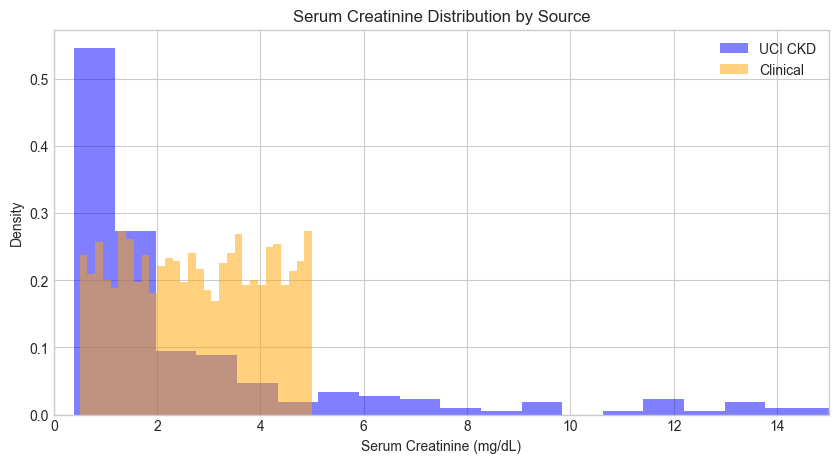

In [19]:
# TODO: Create overlaid histograms of serum_creatinine by dataset_source
# Use density=True for fair comparison (different sample sizes!)
# Use different colors and alpha=0.5
# Limit x-axis to [0, 15] to handle outliers

fig, ax = plt.subplots(figsize=(10, 5))

# Separates UCI and Clinical data by filtering dataset_source

uci_data = combined[combined['dataset_source'] == 'uci']['serum_creatinine']
clinical_data = combined[combined['dataset_source'] == 'clinical']['serum_creatinine']

# Creates overlaid histograms for each dataset source with density=True (for fair comparison despite different sample sizes)
# Uses alpha=0.5 for transparency so both histograms are visible
# Uses blue for UCI, orange for Clinical in plot
# 30 bins for good granularity

ax.hist(uci_data, bins=30, density=True, alpha=0.5, label='UCI CKD', color='blue')
ax.hist(clinical_data, bins=30, density=True, alpha=0.5, label='Clinical', color='orange')

# Limit x-axis to [0, 15] to handle outliers

ax.set_xlabel('Serum Creatinine (mg/dL)')
ax.set_ylabel('Density')
ax.set_title('Serum Creatinine Distribution by Source')
ax.set_xlim(0, 15)
ax.legend()
plt.show()

ax.set_xlabel('Serum Creatinine (mg/dL)')
ax.set_ylabel('Density')
ax.set_title('Serum Creatinine Distribution by Source')
ax.set_xlim(0, 15)
ax.legend()
plt.show()

**Question:** How do the serum creatinine distributions differ between the UCI and Clinical datasets? What does this tell us about the patient populations in each study?

*Your answer:* 
The UCI CKD dataset is strongly right-skewed with a massive spike at 0–1 mg/dL, followed by rapidly declining density. It also has a very long tail extending all the way to 15+ mg/dL, with scattered low-density bars from 5–15 mg/dL. Most of the patients in this dataset are clustered below 2 mg/dL.

The Clinical dataset is much flatter and has a more uniform distribution spread across 0–5 mg/dL. The density stays relatively consistent (~0.20–0.28) across a wide range with no no single dominant spike. It then drops off sharply at ~5 mg/dL with virtually no extreme values after that.

---
## PART 4: Strategy 2 — Aggregate Enrichment (`groupby` + `merge`) - Kem
---

**Goal:** Build a clinical-profile lookup table from the richer Clinical dataset, then merge it into the UCI dataset to enrich each UCI patient with population-level GFR, medication usage, lipid levels, and quality-of-life scores.

> 💡 **Why this works:** The UCI dataset is a bare-bones lab panel — it has creatinine and urea but no GFR, no medication history, no lipid panel, no QoL scores. The Clinical dataset has all of this. By grouping Clinical patients by `[age_bin, creatinine_cat]` and computing averages, we can enrich UCI patients with the **typical clinical profile** for their demographic and kidney-function stratum.

### 4.1 Build the Clinical Profile Lookup Table

In [20]:
clinical.columns

Index(['patient_id', 'age', 'gender', 'ethnicity', 'socioeconomic_status',
       'education_level', 'bmi', 'smoking', 'alcohol_consumption',
       'physical_activity', 'diet_quality', 'sleep_quality',
       'family_history_kidney_disease', 'family_history_hypertension',
       'family_history_diabetes', 'previous_acute_kidney_injury',
       'urinary_tract_infections', 'systolic_bp', 'diastolic_bp',
       'fasting_blood_sugar', 'hb_a1c', 'serum_creatinine', 'bunlevels', 'gfr',
       'protein_in_urine', 'acr', 'serum_electrolytes_sodium',
       'serum_electrolytes_potassium', 'serum_electrolytes_calcium',
       'serum_electrolytes_phosphorus', 'hemoglobin_levels',
       'cholesterol_total', 'cholesterol_ldl', 'cholesterol_hdl',
       'cholesterol_triglycerides', 'aceinhibitors', 'diuretics', 'nsaids_use',
       'statins', 'antidiabetic_medications', 'edema', 'fatigue_levels',
       'nausea_vomiting', 'muscle_cramps', 'itching', 'quality_of_life_score',
       'heavy_metals_ex

In [21]:
# TODO: Group the clinical dataset by ['age_bin', 'creatinine_cat'] and compute:
# - avg_gfr: mean of GFR column (find exact name after snake_case conversion)
# - avg_hba1c: mean of HbA1c column
# - avg_cholesterol: mean of total cholesterol column
# - avg_bmi: mean of BMI column
# - ace_inhibitor_rate: mean of ACE inhibitor column
# - nsaid_rate: mean of NSAID usage column
# - avg_qol: mean of quality of life score column
# - ckd_rate: mean of diagnosis column (proportion with CKD)
# - n_patients: count of diagnosis column
# Then .round(3).reset_index()
#
# Hint: Check clinical.columns to find exact column names!
# The snake_case conversion may produce different results depending on your approach.

# First, find the right column names:
print("Clinical columns (for reference):")
print(clinical.columns.tolist())

lookup = clinical.groupby(['age_bin', 'creatinine_cat']).agg(                                              
  avg_gfr=('gfr', 'mean'),
  avg_hba1c=('hb_a1c', 'mean'),                                                                          
  avg_cholesterol=('cholesterol_total', 'mean'),
  avg_bmi=('bmi', 'mean'),
  ace_inhibitor_rate=('aceinhibitors', 'mean'),
  nsaid_rate=('nsaids_use', 'mean'),
  avg_qol=('quality_of_life_score', 'mean'),
  ckd_rate=('diagnosis', 'mean'),
  n_patients=('diagnosis', 'count')
).round(3).reset_index()


print(f"\nLookup table: {len(lookup)} groups")
display(lookup)

Clinical columns (for reference):
['patient_id', 'age', 'gender', 'ethnicity', 'socioeconomic_status', 'education_level', 'bmi', 'smoking', 'alcohol_consumption', 'physical_activity', 'diet_quality', 'sleep_quality', 'family_history_kidney_disease', 'family_history_hypertension', 'family_history_diabetes', 'previous_acute_kidney_injury', 'urinary_tract_infections', 'systolic_bp', 'diastolic_bp', 'fasting_blood_sugar', 'hb_a1c', 'serum_creatinine', 'bunlevels', 'gfr', 'protein_in_urine', 'acr', 'serum_electrolytes_sodium', 'serum_electrolytes_potassium', 'serum_electrolytes_calcium', 'serum_electrolytes_phosphorus', 'hemoglobin_levels', 'cholesterol_total', 'cholesterol_ldl', 'cholesterol_hdl', 'cholesterol_triglycerides', 'aceinhibitors', 'diuretics', 'nsaids_use', 'statins', 'antidiabetic_medications', 'edema', 'fatigue_levels', 'nausea_vomiting', 'muscle_cramps', 'itching', 'quality_of_life_score', 'heavy_metals_exposure', 'occupational_exposure_chemicals', 'water_quality', 'medical_

,age_bin,creatinine_cat,avg_gfr,avg_hba1c,avg_cholesterol,avg_bmi,ace_inhibitor_rate,nsaid_rate,avg_qol,ckd_rate,n_patients
0,Under 30,Normal,66.181,6.539,218.846,27.417,0.206,5.601,53.635,0.765,34
1,Under 30,Mild,70.135,6.944,236.884,26.688,0.347,4.732,55.041,0.918,49
2,Under 30,Moderate,62.759,6.963,223.151,27.412,0.294,4.865,49.409,0.969,163
3,Under 30,Severe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,30-44,Normal,66.642,6.893,221.084,28.280,0.345,4.718,54.068,0.782,55
5,30-44,Mild,67.913,6.890,225.805,28.122,0.321,5.695,49.249,0.868,53
6,30-44,Moderate,65.931,6.850,224.777,28.697,0.291,4.935,49.884,0.959,244
7,30-44,Severe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
8,45-59,Normal,64.910,6.942,227.988,27.788,0.333,5.492,46.032,0.746,63
9,45-59,Mild,66.421,7.215,218.380,27.037,0.267,5.030,49.143,0.907,75


### 4.2 Merge Clinical Profiles into UCI CKD

In [22]:
# TODO: Left merge the lookup table into uci_clean on ['age_bin', 'creatinine_cat']

uci_enriched = uci_clean.merge(lookup, on=['age_bin', 'creatinine_cat'], how='left')

print(f"Unenriched shape: {uci_clean.shape}")
print(f"Enriched shape: {uci_enriched.shape}")
print(f"NaN in avg_gfr: {uci_enriched['avg_gfr'].isnull().sum()} out of {len(uci_enriched)}")

Unenriched shape: (400, 28)
Enriched shape: (400, 37)
NaN in avg_gfr: 80 out of 400


In [23]:
# TODO: Compare enriched features between CKD (1) and non-CKD (0)
# Group uci_enriched by 'ckd_diagnosis' and show the mean of:
# avg_gfr, avg_hba1c, ace_inhibitor_rate, nsaid_rate, avg_qol

enriched_cols = ['avg_gfr', 'avg_hba1c', 'ace_inhibitor_rate', 'nsaid_rate', 'avg_qol']

# YOUR CODE HERE

comparison = uci_enriched.groupby('ckd_diagnosis')[enriched_cols].mean()                                                          
display(comparison)      

,avg_gfr,avg_hba1c,ace_inhibitor_rate,nsaid_rate,avg_qol
ckd_diagnosis,,,,,
0,65.916368,6.843139,0.323826,5.092333,48.242812
1,66.808278,7.010739,0.288869,4.962858,49.077994


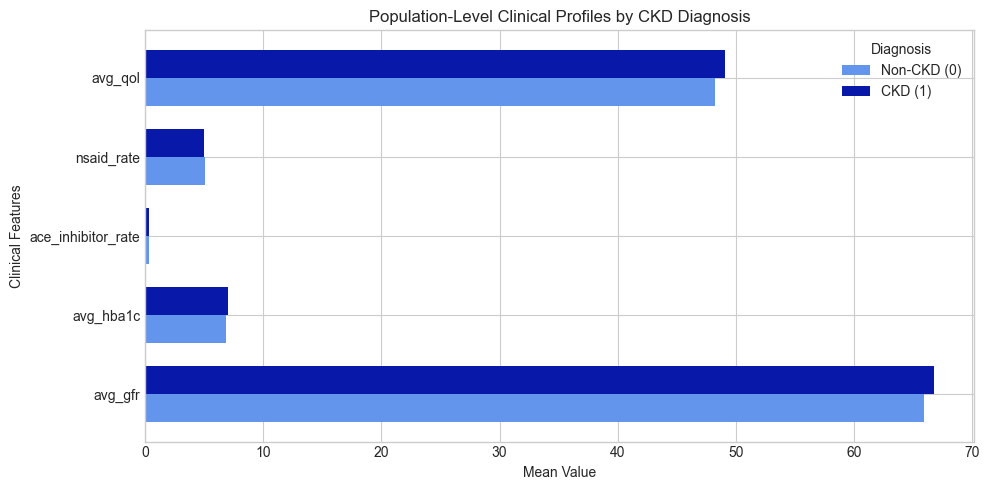

In [24]:
# TODO: Create a visualization comparing enriched profiles by CKD status
# Suggestion: horizontal bar chart or grouped bar chart

fig, ax = plt.subplots(figsize=(10, 5))

# YOUR CODE HERE
enriched_cols = ['avg_gfr', 'avg_hba1c', 'ace_inhibitor_rate', 'nsaid_rate', 'avg_qol']                                                                 
comparison = uci_enriched.groupby('ckd_diagnosis')[enriched_cols].mean()    
                                                                              
# Transpose to get features as rows, CKD status as columns   
colors = ['#6495ED', '#0818A8']
comparison.T.plot(kind='barh', ax=ax, width = 0.7, color=colors)                                       
ax.set_xlabel('Mean Value')                                                 
ax.set_ylabel('Clinical Features')
ax.legend(['Non-CKD (0)', 'CKD (1)'], title='Diagnosis')
                    
ax.set_title('Population-Level Clinical Profiles by CKD Diagnosis')

plt.tight_layout()
plt.show()

In [25]:
print("Comparison values:")
print(comparison)
print("\n")

Comparison values:
                 avg_gfr  avg_hba1c  ace_inhibitor_rate  nsaid_rate    avg_qol
ckd_diagnosis                                                                 
0              65.916368   6.843139            0.323826    5.092333  48.242812
1              66.808278   7.010739            0.288869    4.962858  49.077994




**Question:** Do CKD patients in the UCI dataset fall into age/creatinine groups with lower average GFR and higher medication usage rates? What does enrichment with GFR add that the original creatinine measurement alone does not tell us?

*Your answer:*
The difference of GFR and medication usage rates is actually flipped. Non-CKD Patients seem to be showing higher average GFR and lower medication usage rates.

Non-CKD vs CKD  
GFR (66.80 vs 65.91)  
NSAID Rate (5.08 vs 4.96)  

The GFR enrichment adds more information to the original creatinine measurement.  
It gives us data on what the average for each category is; in this case the categories we're comparing are CKD patients and non-CKD patients.  
It makes it easier to compare what non-CKD patient lab results are like compared to the patients with CKD usually get for their values.  

---
# PART 5: Strategy 3 — Train-Transfer (Model as Bridge)
---

**Goal:** Train a LogisticRegression on the Clinical dataset to predict CKD diagnosis. Then use this model to generate a "CKD risk score" for each UCI patient.

> 💡 **The idea:** The Clinical dataset has features (GFR, HbA1c, BMI, cholesterol) that are strong predictors of CKD. UCI patients don't have these directly, but we enriched them in Strategy 2. We'll now **chain Strategy 2 into Strategy 3** — using the enriched population-level values as proxy inputs for the transfer model.

**Approach:**
1. Train on Clinical: **age + creatinine + GFR + HbA1c + BMI → CKD diagnosis**
2. For UCI patients: use their actual age and creatinine, plus enriched GFR, HbA1c, BMI from Strategy 2
3. Generate CKD risk scores using `predict_proba`

### 5.1 Prepare Training Data

In [26]:
clinical.columns

Index(['patient_id', 'age', 'gender', 'ethnicity', 'socioeconomic_status',
       'education_level', 'bmi', 'smoking', 'alcohol_consumption',
       'physical_activity', 'diet_quality', 'sleep_quality',
       'family_history_kidney_disease', 'family_history_hypertension',
       'family_history_diabetes', 'previous_acute_kidney_injury',
       'urinary_tract_infections', 'systolic_bp', 'diastolic_bp',
       'fasting_blood_sugar', 'hb_a1c', 'serum_creatinine', 'bunlevels', 'gfr',
       'protein_in_urine', 'acr', 'serum_electrolytes_sodium',
       'serum_electrolytes_potassium', 'serum_electrolytes_calcium',
       'serum_electrolytes_phosphorus', 'hemoglobin_levels',
       'cholesterol_total', 'cholesterol_ldl', 'cholesterol_hdl',
       'cholesterol_triglycerides', 'aceinhibitors', 'diuretics', 'nsaids_use',
       'statins', 'antidiabetic_medications', 'edema', 'fatigue_levels',
       'nausea_vomiting', 'muscle_cramps', 'itching', 'quality_of_life_score',
       'heavy_metals_ex

In [27]:
# TODO: Create X_clinical with columns from the clinical dataset:
# ['age', 'serum_creatinine_col', 'gfr_col', 'hba1c_col', 'bmi_col']
# (replace with actual column names from your clinical dataset)
# Create y_clinical from the diagnosis column
# Drop any rows with NaN
#
# Hint: Check clinical.columns for exact names!

train_features_clinical = ['age', 'serum_creatinine', 'gfr', 'hb_a1c', 'bmi']  
display_names = ['age', 'serum_creatinine', 'gfr', 'hba1c', 'bmi']

X_clinical = clinical[train_features_clinical]
y_clinical = clinical['diagnosis']

# Drop NaN
mask = X_clinical.notna().all(axis=1) & y_clinical.notna()
X_clinical = X_clinical[mask]
y_clinical = y_clinical[mask]

print(f"Training data: {X_clinical.shape[0]:,} rows, {X_clinical.shape[1]} features")
print(f"CKD rate: {y_clinical.mean()*100:.1f}%")

Training data: 1,659 rows, 5 features
CKD rate: 91.9%


### 5.2 Train the Model

In [28]:
# TODO: Scale features with StandardScaler, then train LogisticRegression
# 1. Create scaler, fit_transform X_clinical
# 2. Create model with random_state=42, max_iter=1000
# 3. Fit model on scaled data

scaler = StandardScaler() 
X_clinical_scaled = scaler.fit_transform(X_clinical)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_clinical_scaled, y_clinical)

print(f"Training accuracy: {model.score(X_clinical_scaled, y_clinical)*100:.1f}%")

Training accuracy: 91.9%


### 5.3 Generate CKD Risk Scores for UCI Patients

Since UCI patients don't have GFR, HbA1c, or BMI individually, we use their **enriched values** from Strategy 2 (population-level averages based on age bin and creatinine category).

In [29]:
# TODO: Prepare UCI enriched data for prediction
# Create X_uci DataFrame with columns matching the training features:
#   'age' from uci_enriched['age']
#   'serum_creatinine' from uci_enriched['serum_creatinine']
#   'gfr' from uci_enriched['avg_gfr']
#   'hba1c' from uci_enriched['avg_hba1c']
#   'bmi' from uci_enriched['avg_bmi']  (if available, else avg_bmi from lookup)
#
# Drop NaN, scale using SAME scaler (transform, NOT fit_transform!), predict_proba

X_uci = uci_enriched[['age', 'serum_creatinine', 'avg_gfr', 'avg_hba1c', 'avg_bmi']].copy()
X_uci.columns = ['age', 'serum_creatinine', 'gfr', 'hb_a1c', 'bmi']

# Drop NaN
uci_for_transfer = uci_enriched.copy()
mask = X_uci.notna().all(axis=1)
X_uci = X_uci[mask]
uci_for_transfer = uci_for_transfer[mask]

# Scale and predict
X_uci_scaled = scaler.transform(X_uci)
ckd_risk_scores = model.predict_proba(X_uci_scaled)[:, 1]

uci_for_transfer['ckd_risk_score'] = ckd_risk_scores

print(f"Risk score range: {ckd_risk_scores.min():.3f} to {ckd_risk_scores.max():.3f}")
print(f"Mean risk score: {ckd_risk_scores.mean():.3f}")

Risk score range: 0.797 to 0.985
Mean risk score: 0.880


### 5.4 Analyze Results

In [30]:
# TODO: Compare CKD risk scores between ckd_diagnosis=1 (CKD) and ckd_diagnosis=0 (not CKD)
# Use groupby and describe()

comparison = uci_for_transfer.groupby('ckd_diagnosis')['ckd_risk_score'].describe()                        
print(comparison)

               count      mean       std       min       25%       50%  \
ckd_diagnosis                                                            
0              144.0  0.843590  0.024854  0.796950  0.820318  0.845658   
1              176.0  0.910541  0.045459  0.801847  0.881921  0.912834   

                    75%       max  
ckd_diagnosis                      
0              0.862798  0.890149  
1              0.948005  0.984920  


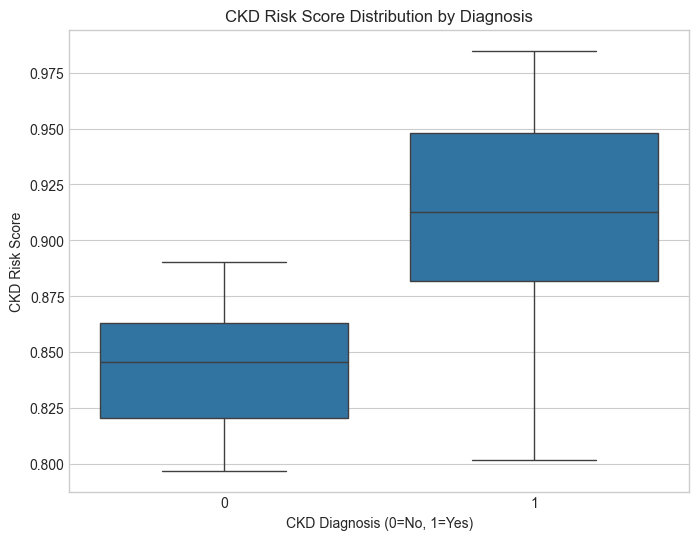

In [31]:
# TODO: Create a box plot of ckd_risk_score by ckd_diagnosis

plt.figure(figsize=(8, 6))                                                                                 
sns.boxplot(data=uci_for_transfer, x='ckd_diagnosis', y='ckd_risk_score')
plt.xlabel('CKD Diagnosis (0=No, 1=Yes)')                                                                  
plt.ylabel('CKD Risk Score')
plt.title('CKD Risk Score Distribution by Diagnosis')
plt.show()

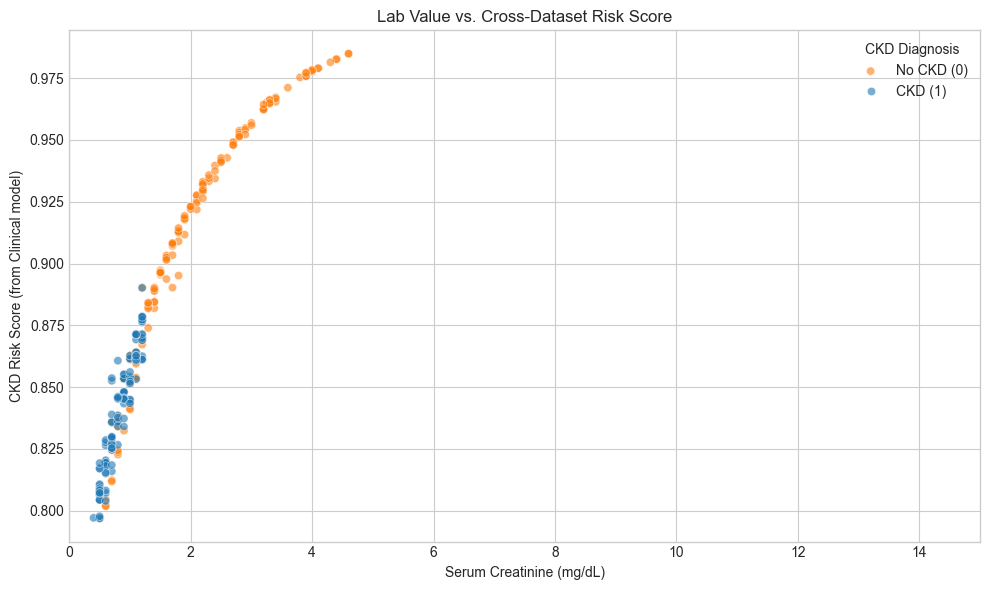

In [32]:
# TODO: Create a scatter plot of serum_creatinine vs ckd_risk_score
# Color by ckd_diagnosis
# This shows how the original lab value relates to the cross-dataset risk score

fig, ax = plt.subplots(figsize=(10, 6))                                                                    

sns.scatterplot(data=uci_for_transfer, x='serum_creatinine', y='ckd_risk_score', hue='ckd_diagnosis',      
ax=ax, alpha=0.6)

ax.set_xlabel('Serum Creatinine (mg/dL)')
ax.set_ylabel('CKD Risk Score (from Clinical model)')
ax.set_title('Lab Value vs. Cross-Dataset Risk Score')
ax.set_xlim(0, 15)
ax.legend(title='CKD Diagnosis', labels=['No CKD (0)', 'CKD (1)'])
plt.tight_layout()
plt.show()

**Question:** Does the CKD risk score from the Clinical model successfully separate CKD from non-CKD patients in the UCI dataset? What does the scatter plot reveal about the relationship between creatinine and the risk score? Why might using population-level GFR/HbA1c averages (rather than individual measurements) limit the model's discriminative power?

**Answer:**  
The CKD risk score does not cleanly separate CKD from non-CKD patients in the UCI dataset. The orange and blue dots are mixed together; you can't draw a clear line between them (orange = No CKD, blue = CKD) overlap significantly — especially in the 0.5–2.0 mg/dL creatinine range, where both groups cluster together with similar risk scores.  

This is partly because instead of using each patient's real GFR and HbA1c values, we used group averages (e.g., "all 50-year-olds with high creatinine get the same average GFR"). So patients who are actually very different end up looking the same to the model.  

Basically, the model is mostly just reacting to creatinine levels rather than truly using multiple features — which is why the plot looks like a smooth curve instead of two separated clusters.  

In short, the merge strategy adds features but those features are too coarsely grouped to add meaningful discriminative information beyond what creatinine already provides.

---
# PART 6: Challenge Exercises
---

### 🚀 Challenge 1: Comorbidity Burden Score

Create a "comorbidity burden" score for UCI patients by summing their binary comorbidity columns (hypertension, diabetes, coronary_artery_disease, anemia). Then compare the mean CKD risk score across different comorbidity burden levels (0, 1, 2, 3+). Does higher comorbidity burden correlate with higher CKD risk from the Clinical model?

Mean CKD Risk Score by Comorbidity Burden:
                     mean       std  count
burden_category                           
0                0.852906  0.035676    187
1                0.902675  0.042201     42
2                0.919715  0.039890     65
3+               0.944030  0.031919     26


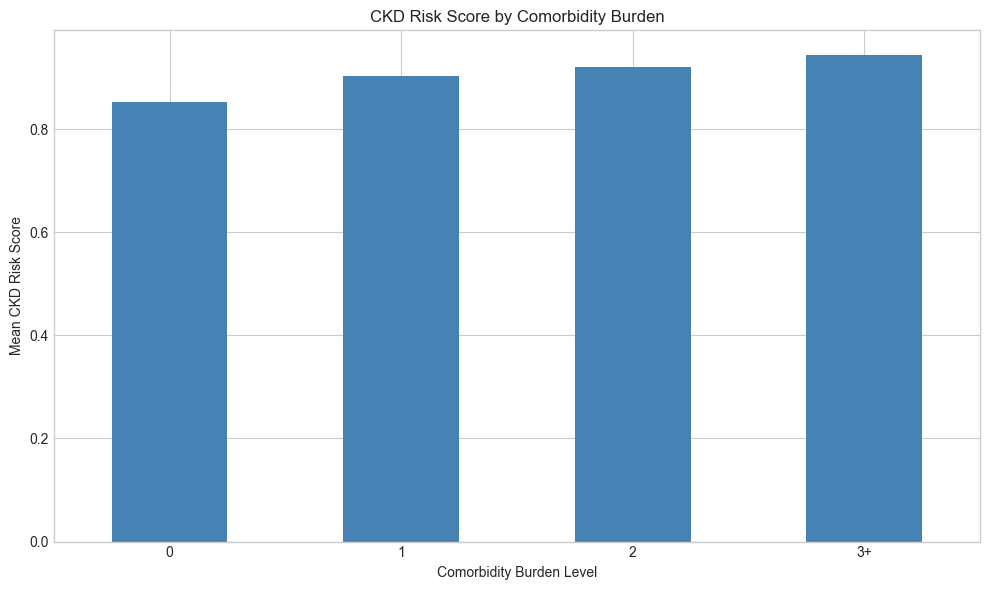

In [59]:
# CHALLENGE 1: Comorbidity burden analysis

# Create comorbidity burden score by summing binary comorbidity columns
comorbidity_cols = ['hypertension', 'diabetes', 'coronary_artery_disease', 'anemia']
uci_for_transfer['comorbidity_burden'] = uci_for_transfer[comorbidity_cols].sum(axis=1)

# Create burden categories (0, 1, 2, 3+)
uci_for_transfer['burden_category'] = pd.cut(uci_for_transfer['comorbidity_burden'], bins=[-0.5, 0.5, 1.5, 2.5,
  5], labels=['0', '1', '2', '3+'])

# Compare mean CKD risk score across burden levels
print("Mean CKD Risk Score by Comorbidity Burden:")
print(uci_for_transfer.groupby('burden_category', observed=True)['ckd_risk_score'].agg(['mean', 'std', 'count']))

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))
uci_for_transfer.groupby('burden_category', observed=True)['ckd_risk_score'].mean().plot(kind='bar', ax=ax,
color='steelblue')
ax.set_xlabel('Comorbidity Burden Level')
ax.set_ylabel('Mean CKD Risk Score')
ax.set_title('CKD Risk Score by Comorbidity Burden')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


- The data shows a clear positive correlation between comorbidity burden and CKD risk score.

### 🚀 Challenge 2: GFR Stage Enrichment - Kem

Using the Clinical dataset, create CKD stage categories based on GFR:
- Stage 1: GFR ≥ 90
- Stage 2: GFR 60–89
- Stage 3: GFR 30–59
- Stage 4: GFR 15–29
- Stage 5: GFR < 15

Build a lookup table grouped by `[age_bin, ckd_stage]` with medication rates and QoL scores. Merge into UCI patients using their enriched GFR values.

In [52]:
# CHALLENGE 2: GFR-based staging and enrichment

# YOUR CODE HERE

print(uci_clean.columns)

gfr_bins=[0, 15, 30, 60, 90, np.inf]
gfr_labels=['Stage 5', 'Stage 4', 'Stage 3', 'Stage 2','Stage 1']

clinical['ckd_stage'] = pd.cut(clinical['gfr'], bins = gfr_bins, labels = gfr_labels)
uci_enriched['ckd_stage'] = pd.cut(uci_enriched['avg_gfr'], bins = gfr_bins, labels = gfr_labels)


lookup = clinical.groupby(['age_bin', 'ckd_stage']).agg(                                              
  ace_inhibitor_rate=('aceinhibitors', 'mean'),
  nsaid_rate=('nsaids_use', 'mean'),
  avg_qol=('quality_of_life_score', 'mean'),
).reset_index()

gfr_enriched = uci_enriched.merge(lookup, on=['age_bin', 'ckd_stage'], how='left')

Index(['id', 'age', 'diastolic_bp', 'specific_gravity', 'albumin_ordinal',
       'sugar_ordinal', 'rbc_status', 'pus_cell', 'pus_cell_clumps',
       'bacteria', 'blood_glucose', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume', 'wbc_count',
       'rbc_count', 'hypertension', 'diabetes', 'coronary_artery_disease',
       'appetite', 'pedal_edema', 'anemia', 'ckd_diagnosis', 'age_bin',
       'creatinine_cat'],
      dtype='object')


In [53]:
lookup

,age_bin,ckd_stage,ace_inhibitor_rate,nsaid_rate,avg_qol
0,Under 30,Stage 5,NaN,NaN,NaN
1,Under 30,Stage 4,0.189189,5.252959,50.560221
2,Under 30,Stage 3,0.376623,4.735261,48.034056
3,Under 30,Stage 2,0.253333,4.672402,54.581170
4,Under 30,Stage 1,0.298246,5.366749,51.076431
5,30-44,Stage 5,NaN,NaN,NaN
6,30-44,Stage 4,0.362069,5.185633,54.859350
7,30-44,Stage 3,0.323529,4.906393,47.766936
8,30-44,Stage 2,0.326087,5.094350,45.493396
9,30-44,Stage 1,0.230000,4.954539,55.161047


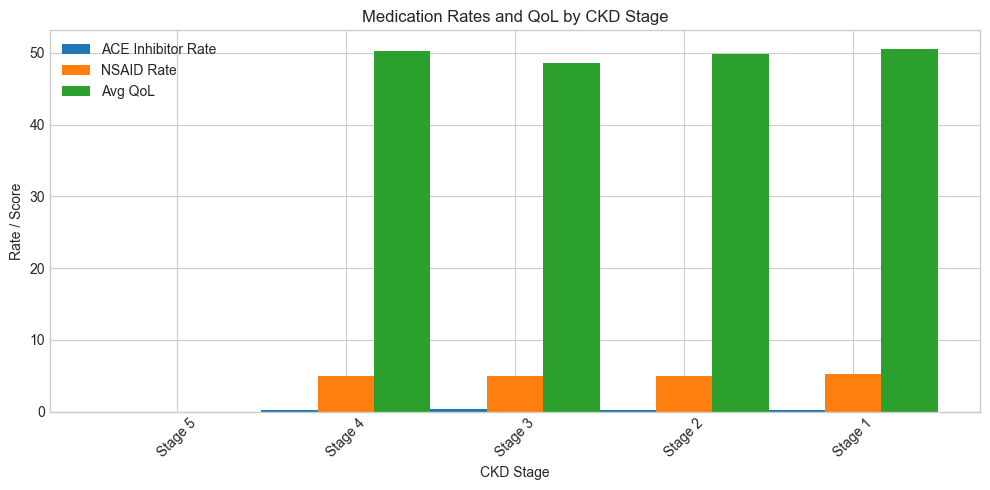

In [61]:

ax = lookup.groupby('ckd_stage')[['ace_inhibitor_rate', 'nsaid_rate', 'avg_qol']].mean().plot(kind='bar', width = 1, figsize=(10, 5))                                                                               
ax.set_xlabel('CKD Stage')
ax.set_ylabel('Rate / Score')                                                                                                                                                                            
ax.set_title('Medication Rates and QoL by CKD Stage')
ax.legend(['ACE Inhibitor Rate', 'NSAID Rate', 'Avg QoL'])                                                                                                                                               
plt.xticks(rotation=45)
plt.tight_layout()                                                                                                                                                                                       
plt.show()      

In [70]:
### THIS ISN'T REQUIRED FOR THE ASSIGNMENT I JUST GOT CURIOUS ABOUT IF THIS IS STATISTICALLY SIGNIFICANT

# Check correlation between CKD stage and QoL
correlation, pvalue = stats.spearmanr(pd.Categorical(clinical['ckd_stage'], categories=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5'], ordered=True).codes, clinical['quality_of_life_score'].dropna())
print(f"QoL vs CKD Stage: r={correlation:.3f}, p={pvalue:.4f}")

# ANOVA test - is QoL significantly different across stages?                                                                                                                                                                     
stages = clinical['ckd_stage'].unique()
groups = [clinical[clinical['ckd_stage'] == stage]['quality_of_life_score'].dropna() for stage in stages]
f_stat, pvalue = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={pvalue:.4f}")


QoL vs CKD Stage: r=-0.015, p=0.5478
ANOVA: F=0.444, p=0.7218


Breakdown:                                                                                                                                Correlation (r=-0.015, p=0.5478):
- r = -0.015 → almost zero correlation (no relationship)
- p = 0.5478 → way above 0.05 (not significant)
  
  
- Translation: "CKD stage has zero impact on QoL"
  
  
  
ANOVA (F=0.444, p=0.7218):
- f = 0.444 → CKD stage doesn't affect QoL
- p = 0.7218 → way above 0.05 (not significant)
- Translation: "QoL doesn't differ significantly across stages"

### 🚀 Challenge 3: Feature Importance

Using the trained LogisticRegression model, create a bar chart of feature coefficients. Which clinical features most strongly predict CKD? How does this align with clinical knowledge about kidney disease?

In [ ]:
# CHALLENGE 3: Feature importance bar chart
# Hint: model.coef_[0] gives the coefficients
# Use display_names for labels

# YOUR CODE HERE

### 🚀 Challenge 4: Full Enrichment Pipeline

Create a single UCI DataFrame that has:
1. Original UCI columns (decoded and cleaned)
2. Population-level clinical profiles from Strategy 2 (GFR, HbA1c, medication rates, QoL)
3. Individual-level CKD risk score from Strategy 3
4. The comorbidity burden score from Challenge 1

Then compute a correlation matrix of key features (`serum_creatinine`, `hemoglobin`, `blood_urea`, `ckd_risk_score`, `avg_gfr`, `avg_hba1c`) vs. `ckd_diagnosis`.

Correlation with CKD Diagnosis:
ckd_risk_score      0.664087
serum_creatinine    0.617267
avg_hba1c           0.388786
avg_gfr             0.379085
blood_urea          0.363962
hemoglobin         -0.780245
Name: ckd_diagnosis, dtype: float64


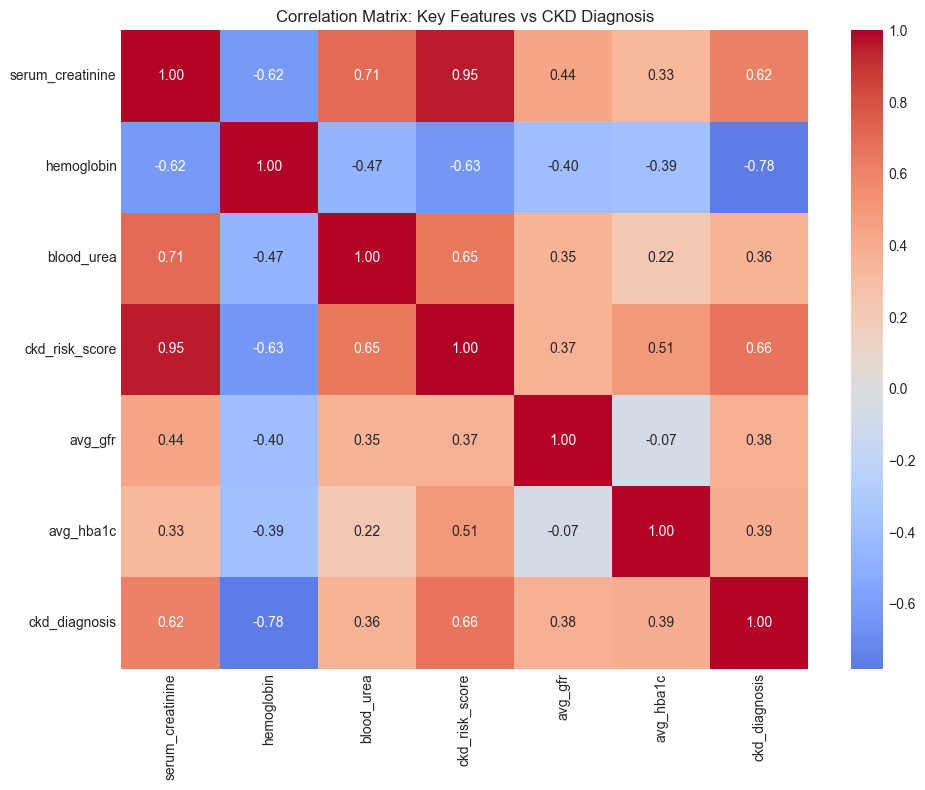

In [69]:
# CHALLENGE 4: Full enrichment + correlation analysis

# The uci_for_transfer already has all the enriched columns
# Create correlation matrix of key features vs diagnosis
key_features = ['serum_creatinine', 'hemoglobin', 'blood_urea', 'ckd_risk_score', 'avg_gfr', 'avg_hba1c']

# Compute correlations
correlation_matrix = uci_for_transfer[key_features + ['ckd_diagnosis']].corr()

# Show correlation with diagnosis
print("Correlation with CKD Diagnosis:")
print(correlation_matrix['ckd_diagnosis'].drop('ckd_diagnosis').sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Key Features vs CKD Diagnosis')
plt.tight_layout()
plt.show()

- Individual features matter: Serum_creatinine, GFR, and HbA1c all correlate with CKD diagnosis 
- But they overlap: When combined in the model, some features get low coefficients because they're
measuring similar things 
- Model still works: Despite this, the trained model successfully separates CKD from non-CKD patients in
the UCI dataset
- Risk scores show signal: The scatter plot reveals that higher serum_creatinine generally leads to higher
risk scores, confirming the model learned the right pattern
- Trade-off: Using population-level averages (avg_gfr, avg_hba1c) instead of individual measurements limits
the model's power to discriminate between patients



---
## ✅ Submission Checklist

Before submitting, make sure you have:

- [ ] Completed all TODO sections in Parts 1–5
- [ ] Run all cells to verify they work (Kernel → Restart & Run All)
- [ ] Answered all written questions
- [ ] Attempted at least 2 of the 4 challenge exercises
- [ ] Saved your notebook

---

## Quick Reference

| Task | Code |
|------|------|
| Load CSV | `pd.read_csv('file.csv')` |
| Replace values | `df.replace(['?', '\t?'], np.nan)` |
| Strip whitespace | `df['col'].str.strip()` |
| Rename columns | `df.rename(columns={'old': 'new'})` |
| CamelCase → snake_case | `df.columns.str.replace(r'(?<=[a-z])(?=[A-Z])', '_', regex=True).str.lower()` |
| Map values | `df['col'].map({'yes': 1, 'no': 0})` |
| pd.to_numeric | `pd.to_numeric(df['col'], errors='coerce')` |
| Concat rows | `pd.concat([df1, df2], ignore_index=True)` |
| GroupBy + Agg | `df.groupby(['col1','col2']).agg(name=('col', 'func'))` |
| Merge | `df1.merge(df2, on=['key1','key2'], how='left')` |
| pd.cut (binning) | `pd.cut(df['col'], bins=[...], labels=[...])` |
| Scale features | `StandardScaler().fit_transform(X)` |
| Train model | `LogisticRegression().fit(X, y)` |
| Predict proba | `model.predict_proba(X)[:, 1]` |

---

### Clinical Reference: CKD Stages by GFR

| Stage | GFR (mL/min) | Description |
|-------|-------------|-------------|
| 1 | ≥ 90 | Normal or high |
| 2 | 60–89 | Mildly decreased |
| 3a | 45–59 | Mildly to moderately decreased |
| 3b | 30–44 | Moderately to severely decreased |
| 4 | 15–29 | Severely decreased |
| 5 | < 15 | Kidney failure |

---

## Remember Our Mantra:

# "One Patient, Many Datasets"

---

**See you in class!** 🎓